In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from astropy.cosmology import FlatLambdaCDM
from astropy.io import fits
 
plt.ion()
cosmo = FlatLambdaCDM(H0=100., Om0=0.31)

In [3]:
bgs_path = '/global/cfs/cdirs/desi/survey/catalogs/DA2/LSS/loa-v1/LSScats/v2/nonKP'

#-- Data catalogs
bgs_data = bgs_path + '/BGS_BRIGHT_clustering.dat.fits'
bgs_rand = bgs_path + '/BGS_BRIGHT_{irand}_clustering.ran.fits'
bgs_ngc_data = bgs_path + '/BGS_BRIGHT_NGC_clustering.dat.fits'
bgs_ngc_rand = bgs_path + '/BGS_BRIGHT_NGC_clustering.ran.fits'
bgs_sgc_data = bgs_path + '/BGS_BRIGHT_SGC_clustering.dat.fits'
bgs_sgc_rand = bgs_path + '/BGS_BRIGHT_SGC_clustering.ran.fits' 

#- N(z) files
bgs_nz_ngc = bgs_path + '/BGS_BRIGHT_NGC_nz.txt'
bgs_nz_sgc = bgs_path + '/BGS_BRIGHT_SGC_nz.txt'
'''
jbautist@login22:nonKP$ ll BGS_BRIGHT*.dat.fits
-rwxrwxr-x 1 desica desi   999M Jul  9  2025 BGS_BRIGHT_clustering.dat.fits
-rwxrwxr-x 1 desica desi   800M Jul  9  2025 BGS_BRIGHT_NGC_clustering.dat.fits
-rwxrwxr-x 1 desica desi   320M Jul  9  2025 BGS_BRIGHT_SGC_clustering.dat.fits
-rwxrwxr-x 1 desica desi   999M Jul 11  2025 BGS_BRIGHT_zcmb_clustering.dat.fits
-rwxrwxr-x 1 desica desi   800M Jul 11  2025 BGS_BRIGHT_zcmb_NGC_clustering.dat.fits
-rwxrwxr-x 1 desica desi   320M Jul 11  2025 BGS_BRIGHT_zcmb_SGC_clustering.dat.fits
'''
'''
#area is 3703.5136square degrees
#effective area is 3610.678582723435square degrees
#zmid zlow zhigh n(z) Nbin Vol_bin
0.005 0.0 0.01 0.382231621210268 3749.051078915596 9808.322678916247
0.015 0.01 0.02 0.22223764657626455 15133.999725222588 68098.2720901389
0.025 0.02 0.03 0.11984998716562273 21949.50158214569 183141.45959659806
0.035 0.03 0.04 0.09376434111605833 33123.76953756809 353266.1686020766
'''

'\n#area is 3703.5136square degrees\n#effective area is 3610.678582723435square degrees\n#zmid zlow zhigh n(z) Nbin Vol_bin\n0.005 0.0 0.01 0.382231621210268 3749.051078915596 9808.322678916247\n0.015 0.01 0.02 0.22223764657626455 15133.999725222588 68098.2720901389\n0.025 0.02 0.03 0.11984998716562273 21949.50158214569 183141.45959659806\n0.035 0.03 0.04 0.09376434111605833 33123.76953756809 353266.1686020766\n'

In [4]:
def read_nz(filename):
    zcen, zlow, zhigh, nz, nbin, vol_bin = np.loadtxt(filename, unpack=True)
    return {'zcen': zcen, 'zlow': zlow, 'zhigh': zhigh, 'nz': nz, 'nbin': nbin, 'vol_bin': vol_bin}

In [5]:
nz_ngc = read_nz(bgs_nz_ngc)
nz_sgc = read_nz(bgs_nz_sgc)

In [23]:
a = fits.open(bgs_data)[1].data
print(a.size)
w = a['Z']< 0.10
print(np.sum(w))
for col in a.columns: 
    print(col)
data = a[w] 

np.unique(data['FRAC_TLOBS_TILES'], return_counts=True)

7875016
1145825
name = 'TARGETID'; format = 'K'
name = 'TILEID'; format = 'K'
name = 'Z'; format = 'D'
name = 'NTILE'; format = 'K'
name = 'RA'; format = 'D'
name = 'DEC'; format = 'D'
name = 'PHOTSYS'; format = '1A'
name = 'FRAC_TLOBS_TILES'; format = 'D'
name = 'WEIGHT_ZFAIL'; format = 'D'
name = 'BITWEIGHTS'; format = '2K'
name = 'PROB_OBS'; format = 'D'
name = 'WEIGHT'; format = 'D'
name = 'WEIGHT_COMP'; format = 'D'
name = 'WEIGHT_SYS'; format = 'D'
name = 'flux_g_dered'; format = 'E'
name = 'flux_r_dered'; format = 'E'
name = 'flux_z_dered'; format = 'E'
name = 'flux_w1_dered'; format = 'E'
name = 'flux_w2_dered'; format = 'E'


(array([0.33333333, 0.5       , 0.6       , ..., 0.99942297, 0.99942463,
        1.        ], shape=(5936,), dtype='>f8'),
 array([     1,      4,      1, ...,    334,     77, 497098], shape=(5936,)))

In [16]:
a = fits.open(bgs_rand.format(irand=0))[1].data
print(a.size)
w = a['Z']< 0.10
print(np.sum(w))
for col in a.columns: 
    print(col)
rand = a[w] 

30945106
4506848
name = 'TARGETID'; format = 'K'
name = 'RA'; format = 'D'
name = 'DEC'; format = 'D'
name = 'NTILE'; format = 'K'
name = 'PHOTSYS'; format = '1A'
name = 'FRAC_TLOBS_TILES'; format = 'D'
name = 'Z'; format = 'D'
name = 'WEIGHT'; format = 'D'
name = 'WEIGHT_SYS'; format = 'D'
name = 'WEIGHT_COMP'; format = 'D'
name = 'WEIGHT_ZFAIL'; format = 'D'
name = 'TARGETID_DATA'; format = 'K'
name = 'flux_g_dered'; format = 'E'
name = 'flux_r_dered'; format = 'E'
name = 'flux_z_dered'; format = 'E'
name = 'flux_w1_dered'; format = 'E'
name = 'flux_w2_dered'; format = 'E'


Text(0.5, 1.0, 'BGS Bright Sample (Z < 0.11) - WEIGHT')

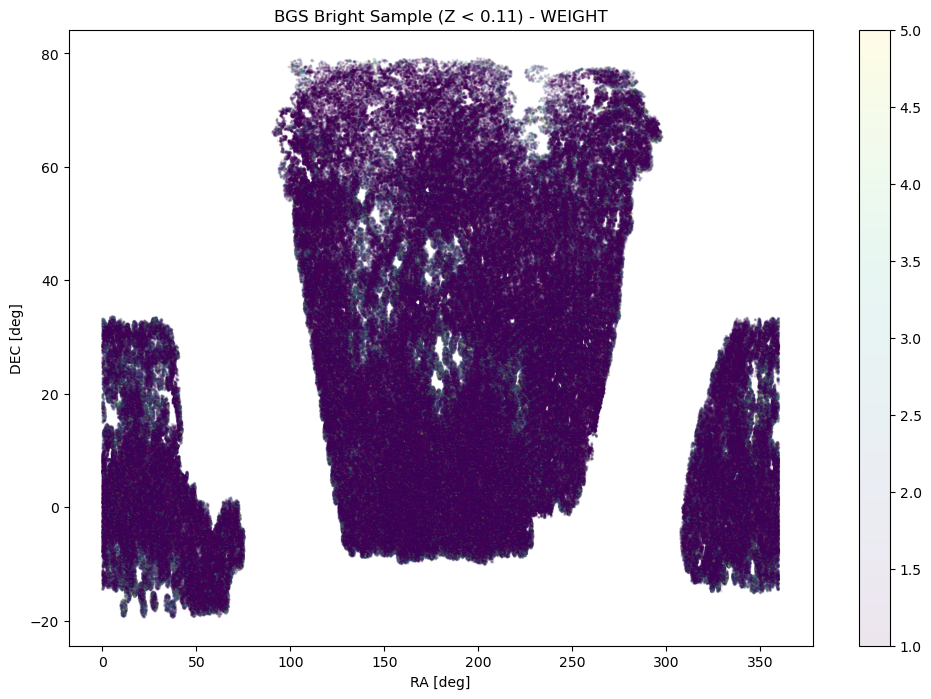

In [ ]:
plt.figure(figsize=(12, 8))
field = 'NTILE'
field = 'WEIGHT_COMP'
field = 'WEIGHT'
plt.scatter(data['RA'], data['DEC'], c=data[field], s=1, alpha=0.1)
plt.colorbar() 
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title(f'BGS Bright Sample (Z < 0.10) - {field}')

Text(0.5, 1.0, 'Randoms - BGS Bright Sample (Z < 0.11) - WEIGHT')

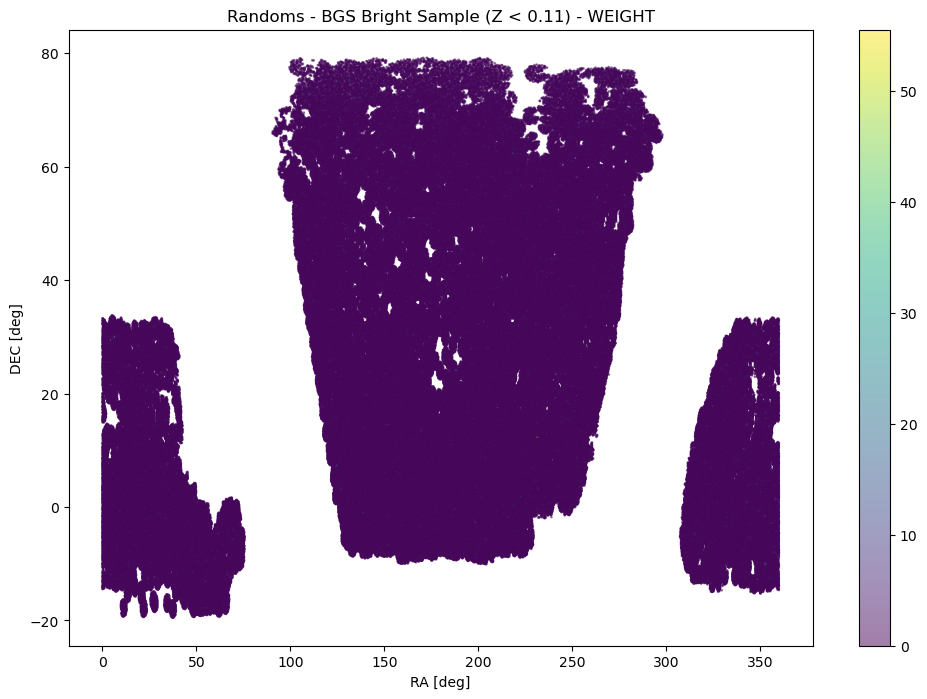

In [15]:
plt.figure(figsize=(12, 8))
plt.scatter(rand['RA'][::10], rand['DEC'][::10], c=rand[field][::10], s=1, alpha=0.5)
plt.colorbar() 
plt.xlabel('RA [deg]')
plt.ylabel('DEC [deg]')
plt.title(f'Randoms - BGS Bright Sample (Z < 0.11) - {field}')

In [7]:
area_ngc = 8500.3589 # sq deg
area_sgc = 3610.6785 # sq deg

zbins = np.linspace(0, 0.11, 200)
zcen = 0.5*(zbins[:-1]+zbins[1:]) 
zvol = (cosmo.comoving_volume(zbins[1:]).value-cosmo.comoving_volume(zbins[:-1]).value)*(1/(4.*np.pi*((180./np.pi)**2)))

def get_nz(z, weights=None,  area=41253.):
    nz, _ = np.histogram(z, bins=zbins, weights=weights)
    return nz/zvol/area

In [8]:
data_ngc = fits.open(bgs_ngc_data)[1].data
data_sgc = fits.open(bgs_sgc_data)[1].data

(0.0, 0.75)

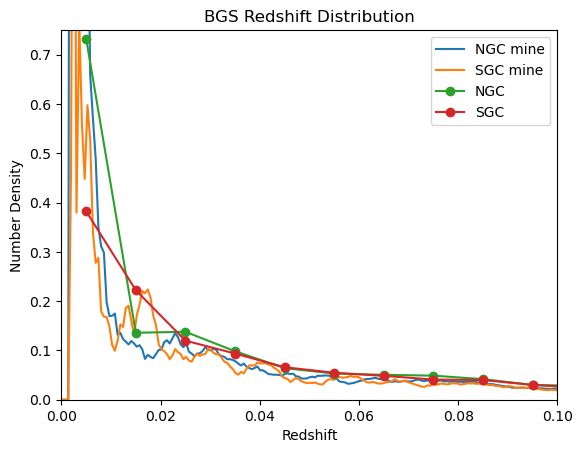

In [12]:
nz_data_ngc = get_nz(data_ngc['Z'], weights=data_ngc['WEIGHT'], area=area_ngc)
nz_data_sgc = get_nz(data_sgc['Z'], weights=data_sgc['WEIGHT'], area=area_sgc)
#d_nz = get_nz(data['Z'], area=area_ngc+area_sgc)

plt.plot(zcen, nz_data_ngc, label='NGC mine')
plt.plot(zcen, nz_data_sgc, label='SGC mine')
plt.plot(nz_ngc['zcen'], nz_ngc['nz'], 'o-', label='NGC')
plt.plot(nz_sgc['zcen'], nz_sgc['nz'], 'o-', label='SGC')
plt.legend()
plt.xlabel('Redshift')
plt.ylabel('Number Density')
plt.title('BGS Redshift Distribution')
plt.xlim(0, 0.10)
plt.ylim(0, 0.75)


1 836047
2 2048022
3 2042107
4 670836
5 30615
[0.58146605 0.58146605 1.16293209 ... 0.92616122 0.87345453 0.76641937]
[0.58067277 0.58067277 1.16134554 ... 0.92499311 0.87235291 0.76542224]


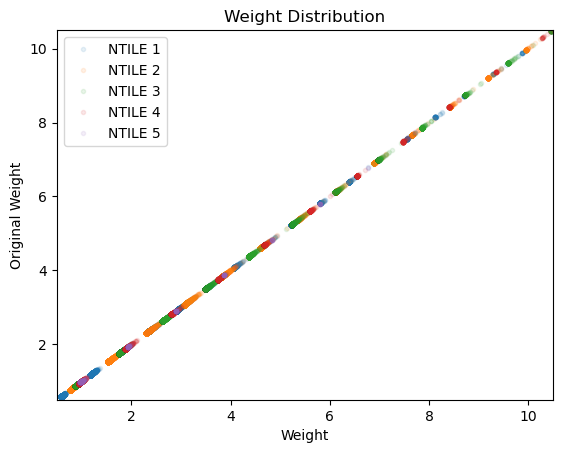

In [30]:
weight = data_ngc['WEIGHT_COMP']*data_ngc['WEIGHT_ZFAIL']*data_ngc['WEIGHT_SYS']
for n in np.unique(data_ngc['NTILE']):

    w = data_ngc['NTILE'] == n
    print(n, np.sum(w))
    weight[w] /= np.mean(weight[w])
    plt.plot(weight[w], data_ngc['WEIGHT'][w], '.', alpha=0.1, label=f'NTILE {n}')
print(data_ngc['WEIGHT'])
print(weight)
plt.legend()
plt.xlabel('Weight')
plt.ylabel('Original Weight')
plt.title('Weight Distribution')
plt.ylim(0.5, 10.5)
plt.xlim(0.5, 10.5)
plt.show()


In [34]:
print(np.sum(weight), weight.size)

5627627.0 5627627
